In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [3]:
image_path = "/Users/peter/Desktop/football_analysis/output_videos/cropped_img.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

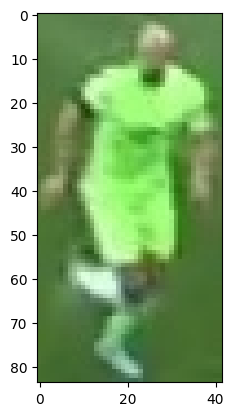

In [4]:
plt.imshow(image)
plt.show()

# take top half of the image 

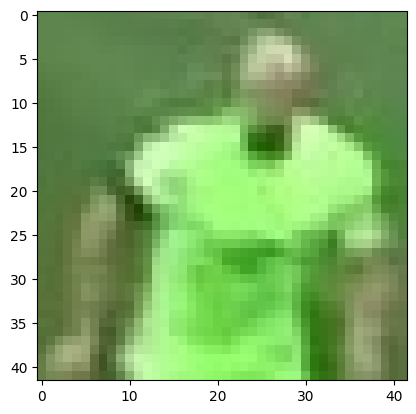

In [5]:
top_half_image = image[0: int(image.shape[0]) // 2, :]
plt.imshow(top_half_image)
plt.show()

# Cluster image

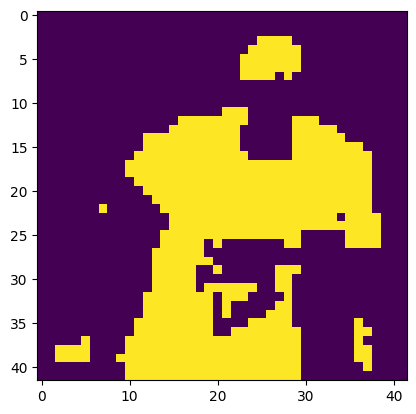

In [8]:
## reshape into 2d array
image_2d = top_half_image.reshape(-1, 3)

## perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

## get cluster labels
labels = kmeans.labels_

##rehape labels back to the original image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

#display cliustered image

plt.imshow(clustered_image)
plt.show()




In [9]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)   
print(non_player_cluster)


0


In [10]:
player_cluster = 1 - non_player_cluster
print(player_cluster)

1


In [11]:
kmeans.cluster_centers_[player_cluster]

array([158.48531952, 230.96545769, 126.48013817])